# Smart Stethoscope: Exploration & Early Analysis

Early exploration and a baseline model (with no audio data).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


## Demographic data

Load demographic data and get a sense of the shape.

In [2]:
path = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/demographic_info.txt"

demographic_data = pd.read_csv(path, sep=' ', header=None)

demographic_data.head()

,0,1,2,3,4,5
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [3]:
demographic_data.shape

(126, 6)

In [4]:
demographic_data

,0,1,2,3,4,5
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0
...,...,...,...,...,...,...
121,222,60.00,M,NaN,NaN,NaN
122,223,NaN,NaN,NaN,NaN,NaN
123,224,10.00,F,NaN,32.3,143.0
124,225,0.83,M,NaN,7.8,74.0


Add column names.

In [5]:
demographic_data.columns = [
    "patient_id",
    "age",
    "sex",
    "adult_bmi",
    "child_weight",
    "child_height"
]

In [6]:
demographic_data.head()

,patient_id,age,sex,adult_bmi,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [7]:
demographic_data.dtypes

patient_id        int64
age             float64
sex              object
adult_bmi       float64
child_weight    float64
child_height    float64
dtype: object

In [8]:
demo_df = demographic_data
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    126 non-null    int64  
 1   age           125 non-null    float64
 2   sex           125 non-null    object 
 3   adult_bmi     75 non-null     float64
 4   child_weight  44 non-null     float64
 5   child_height  42 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.0+ KB


## Diagnosis data

Load diagnosis data and add columns names.

In [9]:
patient_path = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"

diagnosis_df = pd.read_csv(patient_path)

In [10]:
diagnosis_df.columns = [
    "patient_id",
    "disease"
]

diagnosis_df.head()

,patient_id,disease
0,102,Healthy
1,103,Asthma
2,104,COPD
3,105,URTI
4,106,COPD


In [11]:
diagnosis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  125 non-null    int64 
 1   disease     125 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


## Audio and Annotations

Load audio files as a df.

In [12]:
audio_plus = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

files = os.listdir(audio_plus)

audio_files = [f for f in files if f.endswith(".wav")]

audio_df = pd.DataFrame(audio_files, columns=["file_name"])

audio_df.head()

,file_name
0,122_2b1_Tc_mc_LittC2SE.wav
1,113_1b1_Lr_sc_Litt3200.wav
2,178_1b3_Pl_mc_AKGC417L.wav
3,220_1b1_Tc_mc_LittC2SE.wav
4,176_1b3_Tc_mc_AKGC417L.wav


In [13]:
len(files)

1840

Load annotation files as a df.

In [14]:
annotation_files = [f for f in files if f.endswith(".txt")]

len(annotation_files)


920

In [15]:
annotation_df = pd.DataFrame(annotation_files)

annotation_df.head()

,0
0,148_1b1_Al_sc_Meditron.txt
1,130_3p2_Tc_mc_AKGC417L.txt
2,107_2b4_Al_mc_AKGC417L.txt
3,160_2b4_Pr_mc_AKGC417L.txt
4,174_1p4_Ar_mc_AKGC417L.txt


What's inside an annotation file?

In [16]:
sample_file = annotation_files[0]

sample_df = pd.read_csv(
    os.path.join(audio_plus, sample_file),
    sep=r"\s+",
    header=None
)

sample_df.head()

,0,1,2,3
0,0.022,0.364,0,0
1,0.364,2.436,0,0
2,2.436,4.636,0,0
3,4.636,6.793,0,0
4,6.793,8.750,0,0


In [17]:
sample_df.tail()

,0,1,2,3
6,10.764,13.050,0,0
7,13.050,15.193,0,0
8,15.193,17.179,0,0
9,17.179,19.050,0,0
10,19.050,19.993,0,0


In [18]:
sample_df.describe()

,0,1,2,3
count,11.000000,11.000000,11.0,11.0
mean,8.930636,10.746182,0.0,0.0
std,6.692996,6.743262,0.0,0.0
min,0.022000,0.364000,0.0,0.0
25%,3.536000,5.714500,0.0,0.0
50%,8.750000,10.764000,0.0,0.0
75%,14.121500,16.186000,0.0,0.0
max,19.050000,19.993000,0.0,0.0


Extract data from file names

In [19]:
# remove .wav
audio_df["file_name_no_ext"] = audio_df["file_name"].str.replace(".wav", "", regex=False)

# split by underscore
audio_df["split"] = audio_df["file_name_no_ext"].str.split("_")

# create new columns from splits
audio_df["patient_id"] = audio_df["split"].str[0]
audio_df["recording_index"] = audio_df["split"].str[1]
audio_df["chest_location"] = audio_df["split"].str[2]
audio_df["acquisition_mode"] = audio_df["split"].str[3]
audio_df["equipment"] = audio_df["split"].str[4]

# tidy up helper columns
audio_df = audio_df.drop(columns=["file_name_no_ext", "split"])

audio_df.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L


In [20]:
audio_df.dtypes

file_name           object
patient_id          object
recording_index     object
chest_location      object
acquisition_mode    object
equipment           object
dtype: object

Merge diagnosis, audio and demo data on patient ID.

In [22]:
diagnosis_df.columns

Index(['patient_id', 'disease'], dtype='object')

In [23]:
audio_df.columns

Index(['file_name', 'patient_id', 'recording_index', 'chest_location',
       'acquisition_mode', 'equipment'],
      dtype='object')

In [25]:
# Convert diagnosis pid from int to string
diagnosis_df["patient_id"] = diagnosis_df["patient_id"].astype(str)

# Convert audio_df patient_id to string
audio_df["patient_id"] = audio_df["patient_id"].astype(str)

# Merge with diagnosis dataframe (must contain patient_id column)
merged_df = audio_df.merge(diagnosis_df, on="patient_id", how="left")

# Check for missing diagnoses
print("Missing diagnoses:", merged_df["disease"].isna().sum())

# Check class balance
print(merged_df["disease"].value_counts())

Missing diagnoses: 2
disease
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


In [26]:
merged_df.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment,disease
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE,Pneumonia
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200,COPD
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L,COPD
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE,COPD
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L,COPD


In [29]:
# change all patient IDs to integer type
merged_df["patient_id"] = merged_df["patient_id"].astype(int)
demographic_data["patient_id"] = demographic_data["patient_id"].astype(int)

# Merge demographics into your existing merged_df
merged_df = merged_df.merge(demographic_data, on="patient_id", how="left")

# Quick check
merged_df.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment,disease,age,sex,adult_bmi,child_weight,child_height
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE,Pneumonia,66.0,M,33.00,NaN,NaN
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200,COPD,58.0,M,28.41,NaN,NaN
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L,COPD,58.0,M,30.10,NaN,NaN
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE,COPD,66.0,M,35.40,NaN,NaN
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L,COPD,65.0,M,30.10,NaN,NaN


In [32]:
merged_df.columns

Index(['file_name', 'patient_id', 'recording_index', 'chest_location',
       'acquisition_mode', 'equipment', 'disease', 'age', 'sex', 'adult_bmi',
       'child_weight', 'child_height'],
      dtype='object')

#### Add crackles and wheezes!

In [35]:
# Path to folder containing BOTH wav and txt files
audio_plus = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

def summarise_annotation(file_name):
    """
    Given a .wav file name (e.g. 122_2b1_Tc_mc_LittC2SE.wav),
    load the matching .txt annotation file
    and return:
    - has_crackles (0 or 1)
    - has_wheezes (0 or 1)
    """

    # Replace .wav with .txt
    txt_file = file_name.replace(".wav", ".txt")

    # Build full path to annotation file
    full_path = os.path.join(audio_plus, txt_file)

    # Read annotation file (tab separated, no header)
    annotation = pd.read_csv(full_path, sep="\t", header=None)

    # Assign clear column names
    annotation.columns = ["start", "end", "crackles", "wheezes"]

    # If any cycle has crackles = 1 → recording has crackles
    has_crackles = annotation["crackles"].max()

    # If any cycle has wheezes = 1 → recording has wheezes
    has_wheezes = annotation["wheezes"].max()

    return has_crackles, has_wheezes


# Create empty lists to store results
crackles_list = []
wheezes_list = []

# Loop through every recording in merged_df
for file_name in merged_df["file_name"]:

    has_crackles, has_wheezes = summarise_annotation(file_name)

    crackles_list.append(has_crackles)
    wheezes_list.append(has_wheezes)

# Add new columns to dataframe
merged_df["has_crackles"] = crackles_list
merged_df["has_wheezes"] = wheezes_list

# Check result
merged_df.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment,disease,age,sex,adult_bmi,child_weight,child_height,has_crackles,has_wheezes
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE,Pneumonia,66.0,M,33.00,NaN,NaN,0,1
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200,COPD,58.0,M,28.41,NaN,NaN,0,0
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L,COPD,58.0,M,30.10,NaN,NaN,0,0
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE,COPD,66.0,M,35.40,NaN,NaN,1,0
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L,COPD,65.0,M,30.10,NaN,NaN,1,0


In [37]:
merged_df.columns

Index(['file_name', 'patient_id', 'recording_index', 'chest_location',
       'acquisition_mode', 'equipment', 'disease', 'age', 'sex', 'adult_bmi',
       'child_weight', 'child_height', 'has_crackles', 'has_wheezes'],
      dtype='object')

In [41]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file_name         920 non-null    object 
 1   patient_id        920 non-null    int64  
 2   recording_index   920 non-null    object 
 3   chest_location    920 non-null    object 
 4   acquisition_mode  920 non-null    object 
 5   equipment         920 non-null    object 
 6   disease           918 non-null    object 
 7   age               914 non-null    float64
 8   sex               914 non-null    object 
 9   adult_bmi         835 non-null    float64
 10  child_weight      69 non-null     float64
 11  child_height      67 non-null     float64
 12  has_crackles      920 non-null    int64  
 13  has_wheezes       920 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 100.8+ KB


#### Inspecting Diagnosis Classes

In [45]:
# Count recordings per diagnosis
merged_df["disease"].value_counts()

disease
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

In [47]:
# Percentage distribution per diagnosis
merged_df["disease"].value_counts(normalize=True) * 100

disease
COPD              86.383442
Pneumonia          4.030501
Healthy            3.812636
URTI               2.287582
Bronchiectasis     1.742919
Bronchiolitis      1.416122
LRTI               0.217865
Asthma             0.108932
Name: proportion, dtype: float64

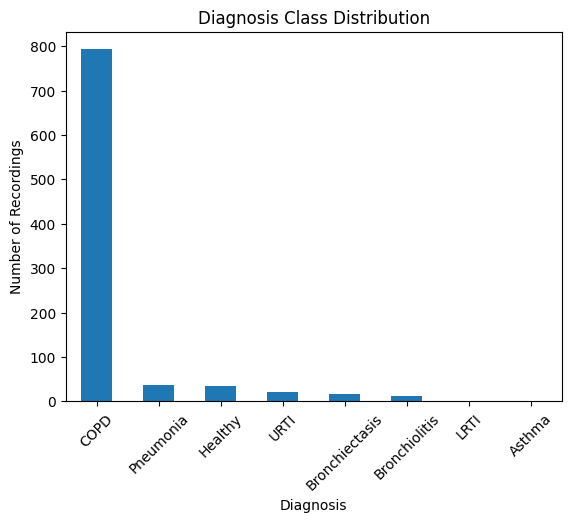

In [ ]:
# Plot class distribution
merged_df["disease"].value_counts().plot(kind="bar")

plt.title("Diagnosis Class Distribution")
plt.ylabel("Number of Recordings")
plt.xlabel("Diagnosis")
plt.xticks(rotation=45)
plt.show()

# A very simple baseline 👀

Just because! Using age, sex, wheezes and crackles. (Adult/Child BMI difference still being worked out)

In [57]:
df.isna().sum()

file_name             0
patient_id            0
recording_index       0
chest_location        0
acquisition_mode      0
equipment             0
disease               0
age                   6
sex                   0
adult_bmi            85
child_weight        851
child_height        853
has_crackles          0
has_wheezes           0
dtype: int64

In [ ]:
# Copy dataframe so we don't break original
df = merged_df.copy()

# Encode sex column (Male/Female → 0/1)
df["sex"] = LabelEncoder().fit_transform(df["sex"])

# Encode diagnosis (string → numbers)
df["disease"] = LabelEncoder().fit_transform(df["disease"])

## Fill 6 missing age values median
df["age"] = df["age"].fillna(df["age"].median())

In [59]:
# Define features and target
X = df[["age", "sex", "has_crackles", "has_wheezes"]]
y = df["disease"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Instantiate model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ 

Accuracy: 0.8967391304347826
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.17      1.00      0.29         1
           3       0.94      1.00      0.97       159
           4       0.62      0.83      0.71         6
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         1

    accuracy                           0.90       184
   macro avg       0.25      0.40      0.28       184
weighted avg       0.83      0.90      0.86       184



/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

🙋‍♀️ What's this saying?

- Predicting majority class (no surprise) --> accuracy 0.897 misleading
- Macro avg f1 = 0.28 --> poor performance in minority classes
- We need to scale some features and check strange values

In [60]:
# check out feature ranges
X.describe()

,age,sex,has_crackles,has_wheezes
count,920.000000,920.000000,920.000000,920.000000
mean,63.804250,0.655435,0.542391,0.365217
std,19.993517,0.489023,0.498471,0.481753
min,0.250000,0.000000,0.000000,0.000000
25%,61.000000,0.000000,0.000000,0.000000
50%,68.000000,1.000000,1.000000,0.000000
75%,75.000000,1.000000,1.000000,1.000000
max,93.000000,2.000000,1.000000,1.000000


In [61]:
# check for infinite values
np.isinf(X).sum()

age             0
sex             0
has_crackles    0
has_wheezes     0
dtype: int64

In [64]:
# why does sex have 3 values?
df["sex"].value_counts()

sex
1    591
0    323
2      6
Name: count, dtype: int64

In [ ]:
# Copy dataframe
df = merged_df.copy()

# Fill missing values simply
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("Unknown")

# Encode sex
df["sex"] = LabelEncoder().fit_transform(df["sex"])

# Encode diagnosis
df["disease"] = LabelEncoder().fit_transform(df["disease"])

# Define features and target
X = df[["age", "sex",  "has_crackles", "has_wheezes"]]
y = df["disease"]

# Fill the 6 missing ages with median
X["age"] = X["age"].fillna(X["age"].median())

# If "2" means Unknown (6 records), replace with most common value (1)
df["sex"] = df["sex"].replace(2, 1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# NEW: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.3967391304347826
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.03      0.50      0.05         2
           2       0.00      0.00      0.00         1
           3       0.98      0.40      0.57       159
           4       0.33      0.17      0.22         6
           5       0.00      0.00      0.00         0
           6       0.11      0.78      0.20         9
           7       0.00      0.00      0.00         6
           8       0.25      1.00      0.40         1

    accuracy                           0.40       184
   macro avg       0.19      0.32      0.16       184
weighted avg       0.87      0.40      0.51       184



/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_16303/3803076228.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["age"] = X["age"].fillna(X["age"].median())
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/pyth

#### How much better is binary classification?

Quick comparative model with binary classification: COPD or not COPD (including healthy)

In [ ]:
# Copy dataframe
df = merged_df.copy()

# Fill missing
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("Unknown")

# Encode sex
df["sex"] = LabelEncoder().fit_transform(df["sex"])
df["sex"] = df["sex"].replace(2, 1)

# Create binary target: 1 = COPD, 0 = everything else
df["copd_binary"] = (df["disease"] == "COPD").astype(int)

# Features
X = df[["age", "sex", "has_crackles", "has_wheezes"]]
y = df["copd_binary"]

# Train/test split (now stratify is safe)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.842391304347826
ROC AUC: 0.8231446540880503
              precision    recall  f1-score   support

           0       0.44      0.56      0.49        25
           1       0.93      0.89      0.91       159

    accuracy                           0.84       184
   macro avg       0.68      0.72      0.70       184
weighted avg       0.86      0.84      0.85       184



/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


## Audio Files (WIP)